In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from src.problems import make_quadratic
from src.stopping_criterion import ExactConvexCertificate
from src.optimizer import minimize

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
n = 2
x_min = np.zeros(n)
x0 = np.r_[1, 1] * 1
# x0 = np.random.normal(0, 10, 20) 
H = np.eye(n) * 2
H[0, 0] = 10

sigma = 0.0
alpha = 0.5
eps = 4

stop_criterion = ExactConvexCertificate(x_min, sigma, alpha, eps)

# H = np.array([[4, 1,], [1, 2]])
fun, true_grad, stoch_grad, proj = make_quadratic(H, sigma, R=np.inf, center=x_min)

eta0 = 0.01
gamma= 0.5

report_interval = 10
x_avg_t, results2 = minimize(fun, grad, proj, x0, eta0, gamma, stop_criterion, report_interval=report_interval, max_iter=10000000)

[Iter     10]  F(x)=2.721722  F_avg(x)=4.151845  Cert=240.103703
[Iter     20]  F(x)=1.846646  F_avg(x)=3.403284  Cert=158.739513
[Iter     30]  F(x)=1.417219  F_avg(x)=2.956309  Cert=125.789441
[Iter     40]  F(x)=1.158724  F_avg(x)=2.644437  Cert=107.008063
[Iter     50]  F(x)=0.985962  F_avg(x)=2.409297  Cert=94.550373
[Iter     60]  F(x)=0.862531  F_avg(x)=2.223352  Cert=85.538201
[Iter     70]  F(x)=0.770052  F_avg(x)=2.071409  Cert=78.640311
[Iter     80]  F(x)=0.698210  F_avg(x)=1.944219  Cert=73.147118
[Iter     90]  F(x)=0.640768  F_avg(x)=1.835750  Cert=68.641967
[Iter    100]  F(x)=0.593744  F_avg(x)=1.741860  Cert=64.862324
[Iter    110]  F(x)=0.554479  F_avg(x)=1.659594  Cert=61.633619
[Iter    120]  F(x)=0.521136  F_avg(x)=1.586773  Cert=58.834729
[Iter    130]  F(x)=0.492408  F_avg(x)=1.521751  Cert=56.378678
[Iter    140]  F(x)=0.467343  F_avg(x)=1.463257  Cert=54.201204
[Iter    150]  F(x)=0.445232  F_avg(x)=1.410289  Cert=52.253675
[Iter    160]  F(x)=0.425537  F_avg(

In [42]:
results = results2
f = results['f']
f_avg = results['f_avg']
F_t_raw = results['F_t_raw']
cert = results['cert']

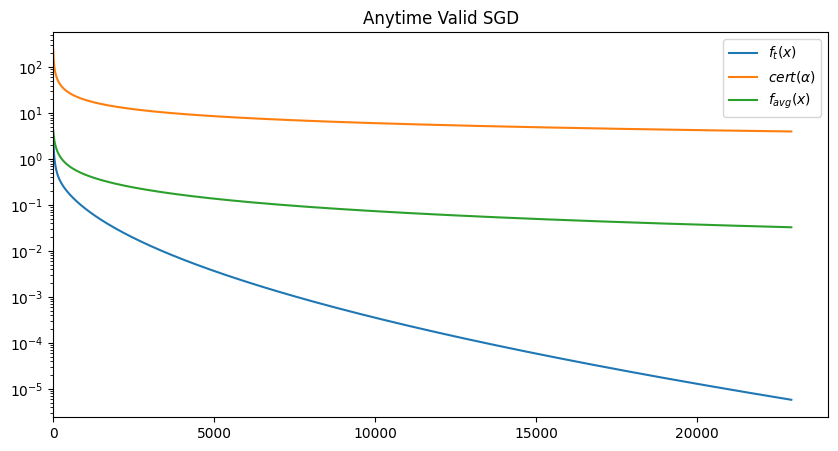

In [43]:
t = np.linspace(1, len(f) * report_interval, len(f))
plt.figure(figsize=(10, 5))
plt.plot(t, f, label=r"$f_t(x)$")
plt.plot(t, cert, label=r"$cert(\alpha)$")
plt.plot(t, f_avg, label=r"$f_{avg}(x)$")
# plt.hlines(y=eps, xmin=0, xmax=len(U_t), linestyles="--", color='black')
# plt.ylim(0, 0.001)
plt.xlim(left=0)
plt.yscale('log')
plt.legend(loc='upper right')
plt.title('Anytime Valid SGD')
plt.show()

### Setup 2